Breakdown time seems so long. Let's plot a long one.

In [1]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
%load_ext watermark
%watermark -v -p pandas,matplotlib,numpy

CPython 3.7.7
IPython 7.16.1

pandas 1.0.5
matplotlib 3.2.2
numpy 1.18.5


In [2]:
base_path = Path('E:\\','Surfdrive','Screening_Data_Mutable')
fit = Path(base_path,'2019','11','07','results','D3_fit.csv')
fit = all_data1 = pd.read_csv(fit)
tau = Path(base_path,'2019','11','07','results','D3_tau.csv')
tau = all_data1 = pd.read_csv(tau,'\t',header=None)
frametime = 5
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c)) 

In [3]:
fit.head()

,Unnamed: 0,start(ns),range(ns),breakdown time(s),midpoint(s),start tau(ns),e_start,e_range,e_halftime,e_midpoint,error,condition,e_breakdown time
0,0,3.505402,-1.271021,250.546459,200.000000,2.242213,0.163631,0.212031,NaN,15.097601,16.0,PDE3A,55.421382
1,1,3.298148,-0.920308,100.420019,200.000000,2.303057,0.026015,0.031396,NaN,2.582711,0.0,PDE3A,9.015632
2,2,3.123814,-0.847791,134.863346,200.000000,2.222798,0.030563,0.037102,NaN,3.490136,0.0,PDE3A,12.073459
3,3,2.986451,-0.657592,42.139706,132.378089,2.309569,0.021848,0.022509,NaN,1.140023,0.0,PDE3A,3.289063
4,4,3.125982,-0.847974,49.516680,135.126679,2.244975,0.026207,0.027036,NaN,1.187613,0.0,PDE3A,3.297159


In [13]:
tau.head()

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
0,2.220445,2.243348,2.240552,2.326280,2.158671,2.273617,2.258518,2.244526,2.253770,2.269362,...,3.081301,3.166175,3.075127,3.143193,3.125563,3.142544,3.156363,3.110541,3.162862,3.115879
1,2.254891,2.283476,2.323302,2.273868,2.331584,2.276048,2.326549,2.345896,2.414014,2.714481,...,3.179124,3.174623,3.194207,3.198114,3.208579,3.227058,3.204608,3.218553,3.231330,3.229343
2,2.281141,2.217342,2.297259,2.184405,2.192184,2.232253,2.254042,2.270968,2.220795,2.287202,...,3.116903,3.109153,3.122060,3.125493,3.126325,3.158738,3.153035,3.141782,3.139618,3.128236
3,2.314024,2.294198,2.310177,2.310385,2.323516,2.307928,2.303915,2.299827,2.281462,2.371419,...,3.158475,3.187946,3.169991,3.179181,3.185410,3.198122,3.183070,3.188008,3.171575,3.174624
4,2.263252,2.251100,2.236672,2.247942,2.244185,2.192811,2.217163,2.243330,2.255075,2.349401,...,3.121253,3.108956,3.165239,3.177293,3.164655,3.175481,3.149709,3.171670,3.121595,3.166541


In [14]:
fit_sel = fit[fit['breakdown time(s)'] > 150]
fit_sel = fit_sel[fit_sel['error']==0]
fit_sel.head()

,Unnamed: 0,start(ns),range(ns),breakdown time(s),midpoint(s),start tau(ns),e_start,e_range,e_halftime,e_midpoint,error,condition,e_breakdown time
362,362,3.17789,-0.82906,189.390669,200.0,2.346746,0.04512,0.056236,NaN,5.790926,0.0,PDE3A,20.147381


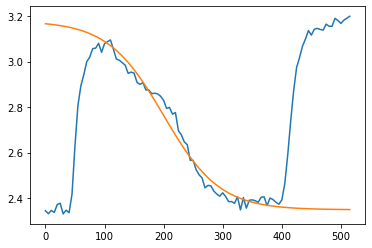

In [15]:
curve_nr = 362;
fit_vals= fit.loc[curve_nr,:]
t_ax = np.arange(0,frametime*len(tau.columns),frametime)
plt.plot(t_ax,tau.loc[curve_nr,:])
plt.plot(t_ax,fit_function(t_ax,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown time(s)'],fit_vals['midpoint(s)']))

In [16]:
fit_vals

Unnamed: 0                 362
start(ns)              3.17789
range(ns)             -0.82906
breakdown time(s)      189.391
midpoint(s)                200
start tau(ns)          2.34675
e_start              0.0451195
e_range              0.0562356
e_halftime                 NaN
e_midpoint             5.79093
error                        0
condition                PDE3A
e_breakdown time       20.1474
Name: 362, dtype: object